# Autoencoder

Goals: Training an Autoencoder on the WaferMap Dataset

In [11]:
# !pip install pandas kagglehub scikit-learn seaborn

In [14]:
import time
import copy
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

SEED = 42

Download the dataset from Kaggle

In [42]:
import kagglehub
# kagglehub.login()

path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print(path)

/Users/purav/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1


In [43]:
print("Loading dataset...")

file_path = "/Users/purav/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl" # Change this to where the LSWMD.pkl is downloaded
# file_path = "../data/LSWMD.pkl"

df_original = pd.read_pickle(file_path)
print(f"Done. {len(df_original)} rows loaded.")

Loading dataset...
Done. 811457 rows loaded.


## Cleaning

1. Rename "trianTestLabel" to "trainTestLabel"

In [44]:
df_original = df_original.rename(columns={"trianTestLabel": "trainTestLabel"})

2. Drop samples with unlabeled `failureType` and unlabeled `trainTestLabel`

In [45]:
df_original["failureType_str"] = df_original["failureType"].astype(str)
df_original["trainTestLabel_str"] = df_original["trainTestLabel"].astype(str)

In [46]:
df_labeled = df_original[
    (df_original["failureType_str"] != "[]") &
    (df_original["trainTestLabel_str"] != "[]")
].copy()

df_labeled[["failureType", "trainTestLabel"]] = (
    df_labeled[["failureType_str", "trainTestLabel_str"]]
    .apply(lambda s: s.str.replace(r"[\[\]']", "", regex=True).str.strip())
)
df_labeled = df_labeled.reset_index(drop=True)

df_labeled contains 172,950 samples that have a `failureType` label

In [47]:
print(f"df_labeled: {len(df_labeled):,} samples\n")
print(df_labeled["failureType"].value_counts())

df_labeled: 172,950 samples

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


df_all contains all 811,457 samples

In [48]:
df_all = df_original.copy().reset_index(drop=True)

In [49]:
print(f"df_all: {len(df_all):,} total samples")
print(f"  labeled: {(df_all['failureType_str'] != '[]').sum():,}")
print(f"  unlabeled: {(df_all['failureType_str'] == '[]').sum():,}")

df_all: 811,457 total samples
  labeled: 172,950
  unlabeled: 638,507


## Visualization

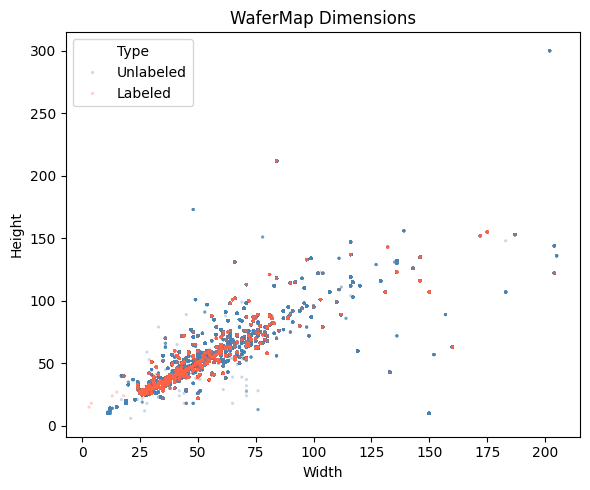

In [50]:
heights = [wm.shape[0] for wm in df_all["waferMap"]]
widths  = [wm.shape[1] for wm in df_all["waferMap"]]

plot_df = pd.DataFrame({
    "Width": widths,
    "Height": heights,
    "Type": ["Labeled" if l else "Unlabeled" for l in df_all["failureType_str"] != "[]"]
}).sort_values("Type", ascending=False) # "Labeled samples are drawn on top

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=plot_df, x="Width", y="Height", hue="Type",
    palette={"Unlabeled": "steelblue", "Labeled": "tomato"},
    s=5, alpha=0.3, linewidth=0
)
plt.title("WaferMap Dimensions")
plt.tight_layout()
plt.show()

## Preprocessing

In [51]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [52]:
IMG_SIZE  = 64
CLASSES = ["none", "Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]
LABEL_MAP = {c: i for i, c in enumerate(CLASSES)}
print(LABEL_MAP)

{'none': 0, 'Edge-Ring': 1, 'Edge-Loc': 2, 'Center': 3, 'Loc': 4, 'Scratch': 5, 'Random': 6, 'Donut': 7, 'Near-full': 8}


Resize and pad strategy
-  Resize while maintaining aspect ratio.
-  Resize longest side to target, pad shorter side with zeros (0 = outside wafer).

In [53]:
def resize_and_pad(wm, target=IMG_SIZE):
    """
    Resize while maintaining aspect ratio.
    Resize longest side to target, pad shorter side with zeros (0 = outside wafer).
    """
    h, w  = wm.shape
    scale = target / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)

    wm_img = Image.fromarray(wm).resize((new_w, new_h), Image.NEAREST)

    pad_h = target - new_h
    pad_w = target - new_w
    wm_padded = np.pad(
        np.array(wm_img),
        ((pad_h // 2, pad_h - pad_h // 2),
         (pad_w // 2, pad_w - pad_w // 2)),
        mode="constant",
        constant_values=0
    )
    return wm_padded

A WaferMap sample before and after each resize strategy

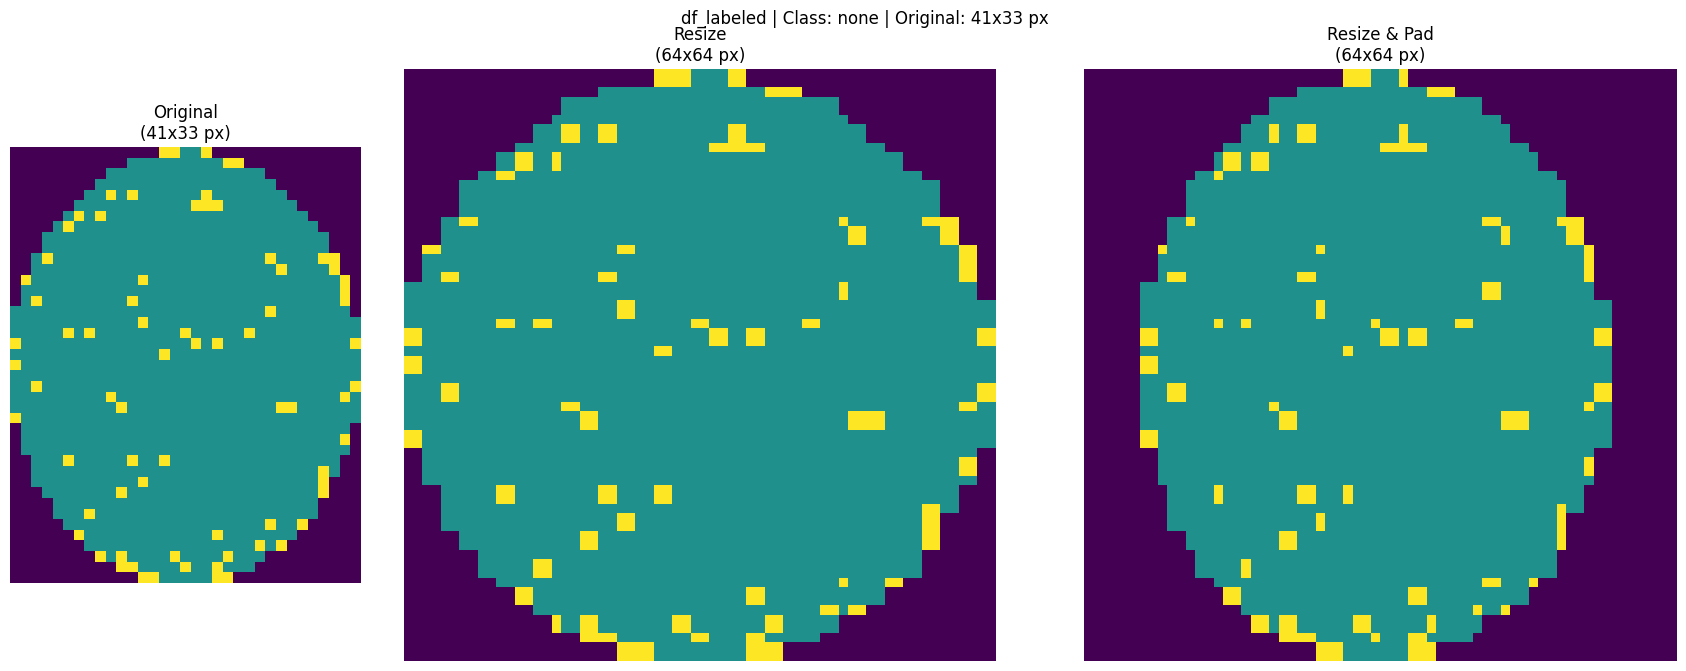

In [54]:
sample_row = df_labeled.sample(1, random_state=np.random.randint(0, 10000)).iloc[0]
wm_raw = np.array(sample_row["waferMap"], dtype=np.float32) / 2.0
wm_resize = np.array(Image.fromarray(wm_raw).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
wm_pad = resize_and_pad(wm_raw)

h, w = wm_raw.shape
scale = 0.1
total_w = w + IMG_SIZE + IMG_SIZE
fig = plt.figure(figsize=(total_w * scale + 1, max(h, IMG_SIZE) * scale + 1))

ax1 = fig.add_axes([0/total_w, 0.1, w/total_w, 0.8])
ax2 = fig.add_axes([w/total_w, 0.1, IMG_SIZE/total_w, 0.8])
ax3 = fig.add_axes([(w+IMG_SIZE)/total_w, 0.1, IMG_SIZE/total_w, 0.8])

ax1.imshow(wm_raw, cmap="viridis", interpolation="nearest")
ax1.set_title(f"Original\n({h}x{w} px)")
ax2.imshow(wm_resize, cmap="viridis", interpolation="nearest")
ax2.set_title(f"Resize\n({IMG_SIZE}x{IMG_SIZE} px)")
ax3.imshow(wm_pad, cmap="viridis", interpolation="nearest")
ax3.set_title(f"Resize & Pad\n({IMG_SIZE}x{IMG_SIZE} px)")

for ax in [ax1, ax2, ax3]:
    ax.axis("off")

plt.suptitle(f"df_labeled | Class: {sample_row['failureType']} | Original: {h}x{w} px", fontsize=12)
plt.show()

Augmentations

In [60]:
AUGMENTATION = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomChoice([
        transforms.Lambda(lambda x: x), # no rotation
        transforms.RandomRotation(degrees=(90, 90), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomRotation(degrees=(180, 180), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomRotation(degrees=(270, 270), interpolation=transforms.InterpolationMode.NEAREST),
    ]),
])

Oversampling/Undersampling

In [61]:
def balance_df(df, oversample=False, oversample_target=2000, undersample=False, undersample_target=50000):
    """
    Apply oversampling and/or undersampling to a dataframe based on failureType.
    Args:
        df: dataframe with failureType column
        oversample: if True, upsample minority classes to oversample_target (excludes "none")
        oversample_target: minimum number of samples per class after oversampling
        undersample: if True, downsample "none" class to undersample_target
        undersample_target: max number of "none" samples after undersampling
    """
    if oversample:
        oversampled = []
        for cls in CLASSES:
            cls_df = df[df["failureType"] == cls]
            if cls != "none" and len(cls_df) < oversample_target:
                extra = cls_df.sample(oversample_target - len(cls_df), replace=True, random_state=SEED)
                cls_df = pd.concat([cls_df, extra])
            oversampled.append(cls_df)
        df = pd.concat(oversampled).sample(frac=1, random_state=SEED)

    if undersample and undersample_target is not None:
        none_df  = df[df["failureType"] == "none"].sample(undersample_target, random_state=SEED)
        other_df = df[df["failureType"] != "none"]
        df = pd.concat([none_df, other_df])

    return df.reset_index(drop=True)

In [62]:
class WaferDataset(Dataset):
    """
    Wafer dataset for autoencoder training.
    Returns (input_tensor, target_tensor), where target == input.
    """
    def __init__(self, df, strategy="pad", augment=False):
        self.df = df.reset_index(drop=True)
        self.strategy = strategy
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _shape_normalize(self, wm):
        if self.strategy == "pad":
            return resize_and_pad(wm)
        else:
            return np.array(
                Image.fromarray(wm).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
            )

    def __getitem__(self, idx):
        wm = np.array(self.df.iloc[idx]["waferMap"], dtype=np.float32)

        wm = wm / 2.0
        wm_array = self._shape_normalize(wm)
        wm_tensor = torch.from_numpy(wm_array).unsqueeze(0)

        if self.augment:
            wm_tensor = AUGMENTATION(wm_tensor)

        return wm_tensor, wm_tensor

### Dataloaders

In [63]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

Create Train/Val/Test splits

In [64]:
VAL_SPLIT = 0.1
TEST_SPLIT = 0.2

df_train_val, df_test = train_test_split(
    df_labeled,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=df_labeled["failureType"]
)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED,
    stratify=df_train_val["failureType"]
)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Train: 121,065 | Val: 17,295 | Test: 34,590


Dataloaders

In [69]:
STRATEGY = "pad"
AUGMENTATIONS = True


OS = False
OS_TARGET = 2000
US = False
US_TARGET = 50000

ENTIRE_DATASET = True

BATCH_SIZE = 512
NUM_WORKERS = 0 # num_workers = number of CPU cores / 2

In [70]:
df_train_balanced = balance_df(
    df_train,
    oversample=OS,
    oversample_target=OS_TARGET,
    undersample=US,
    undersample_target=US_TARGET,
)

df_train_all = pd.concat(
    [df_train_balanced, df_all[df_all["failureType_str"] == "[]"]],
    ignore_index=True,
)

train_df = df_train_all if ENTIRE_DATASET else df_train_balanced

train_loader = DataLoader(
    WaferDataset(
        train_df,
        strategy=STRATEGY,
        augment=AUGMENTATIONS,
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    WaferDataset(
        df_val,
        strategy=STRATEGY,
        augment=False,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    WaferDataset(
        df_test,
        strategy=STRATEGY,
        augment=False,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"Train: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,} | Test: {len(test_loader.dataset):,}")

x, _ = next(iter(train_loader))
print(f"Batch shape: {x.shape}")
print(f"Dtype: {x.dtype}")
print(f"Min: {x.min().item():.3f}, Max: {x.max().item():.3f}")

Train: 759,572 | Val: 17,295 | Test: 34,590
Batch shape: torch.Size([512, 1, 64, 64])
Dtype: torch.float32
Min: 0.000, Max: 1.000


## Training

1. Train an autoencoder on the labeled dataset
2. Run a KNN on the encoder
3. Finetune the trained encoder as a classifier

In [71]:
import torch.nn as nn
from sklearn.metrics import f1_score
torch.manual_seed(SEED)

In [72]:
# Use GPU if available
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print(f"Device: {device}")

Device: mps


In [73]:
results = {}

### AutoEncoder

#### AE_Large

- Uses the Large CNN encoder architecture

In [74]:
class AE_Large(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.encoder_conv = nn.Sequential(
            # Block 1: (1, 64, 64) -> (32, 32, 32)
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: (32, 32, 32) -> (64, 16, 16)
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: (64, 16, 16) -> (128, 8, 8)
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.encoder_dropout = nn.Dropout(0.2)
        self.encoder_fc = nn.Linear(128 * 8 * 8, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(), # (128, 8, 8) -> (64, 16, 16)
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # (64, 16, 16) -> (32, 32, 32)
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1), # (32, 32, 32) -> (1, 64, 64)
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.flatten(1)
        x = self.encoder_dropout(x)
        return self.encoder_fc(x)

    def decode(self, z):
        x = torch.relu(self.decoder_fc(z))
        x = x.view(-1, 128, 8, 8)
        return self.decoder_conv(x)

    def forward(self, x):
        return self.decode(self.encode(x))

autoenc_large = AE_Large(latent_dim=128).to(device)
total_params = sum(p.numel() for p in autoenc_large.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 2,814,017


In [75]:
autoenc_large

AE_Large(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=

#### Training Loop

In [96]:
model = autoenc_large # change this to preferred model arch
model_name = "autoenc_large"

In [97]:
learning_rate = 1e-4
weight_decay = 1e-3
MAX_EPOCHS = 200
PATIENCE = 10

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.MSELoss()

In [98]:
train_losses, val_losses = [], []
best_loss = float("inf")
patience_counter = 0
best_weights = None

start_time = time.time()

for epoch in tqdm(range(MAX_EPOCHS), desc="Epochs"):
    # Train
    model.train()
    running_loss = 0
    for x in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        x = x.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(x), x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # Val
    model.eval()
    running_loss = 0
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device)
            running_loss += criterion(model(x), x).item()
    val_loss = running_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Early stopping on val loss
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    tqdm.write(
        f"Epoch {epoch+1:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"Patience: {patience_counter}/{PATIENCE}"
    )

    if patience_counter >= PATIENCE:
        tqdm.write(f"Early stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time
model.load_state_dict(best_weights)
tqdm.write(f"Restored best model — val loss: {best_loss:.4f}")

results[model_name] = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss":  best_loss,
    "epochs_trained": len(train_losses),
    "max_epochs": MAX_EPOCHS,
    "training_time_sec": elapsed,
    "batch_size": train_loader.batch_size,
    "learning_rate": optimizer.param_groups[0]["lr"],
    "weight_decay": optimizer.param_groups[0]["weight_decay"],
    "patience": PATIENCE,
    "strategy": STRATEGY,
    "n_train": len(train_loader.dataset),
    "n_val": len(val_loader.dataset),
    "n_test": len(test_loader.dataset),
    "SEED": SEED
}

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/1392 [00:00<?, ?it/s]

Epoch 01 | Train: 0.0349 | Val: 0.0266 | Patience: 0/10


Epoch 2:   0%|          | 0/1392 [00:00<?, ?it/s]

Epoch 02 | Train: 0.0190 | Val: 0.0238 | Patience: 0/10


...

Epoch 156 | Train: 0.0093 | Val: 0.0156 | Patience: 8/10


Epoch 157:   0%|          | 0/1392 [00:00<?, ?it/s]

Epoch 157 | Train: 0.0092 | Val: 0.0156 | Patience: 9/10


Epoch 158:   0%|          | 0/1392 [00:00<?, ?it/s]

Epoch 158 | Train: 0.0092 | Val: 0.0157 | Patience: 10/10
Early stopping at epoch 158
Restored best model — val loss: 0.0156


In [99]:
autoenc_trained = copy.deepcopy(model)

#### Reconstructions Visualization

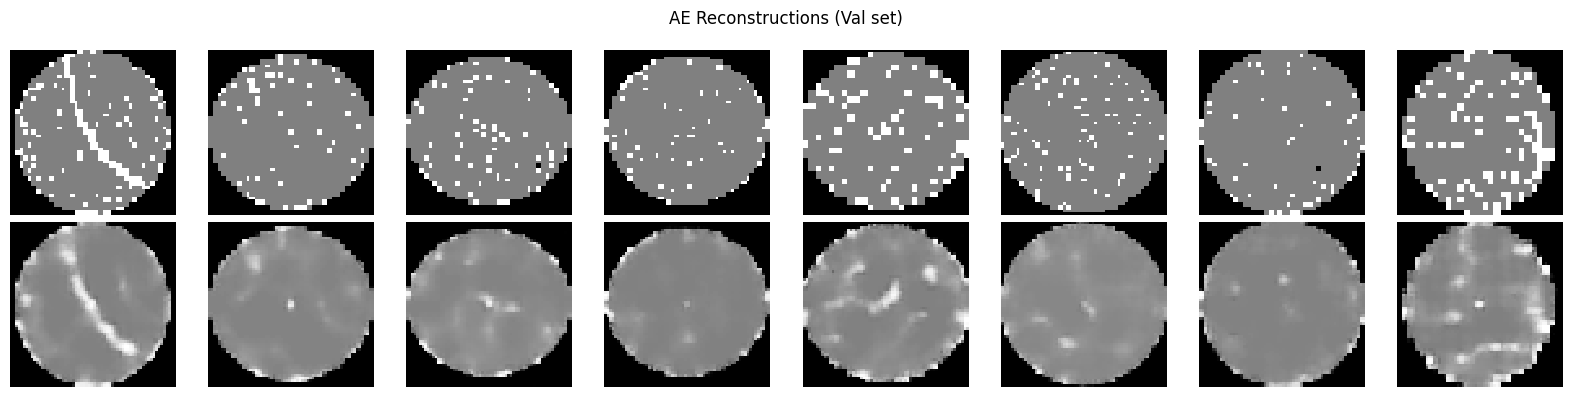

In [100]:
n_samples = 8

model.eval()

x = next(iter(val_loader)).to(device)

with torch.no_grad():
    logits = model(x)
    recon = torch.sigmoid(logits)

n = min(8, x.size(0))
fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))

for i in range(n):
    axes[0, i].imshow(x[i, 0].cpu(), cmap="viridis")
    axes[0, i].set_title("Input")
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i, 0].cpu(), cmap="viridis")
    axes[1, i].set_title("Recon")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

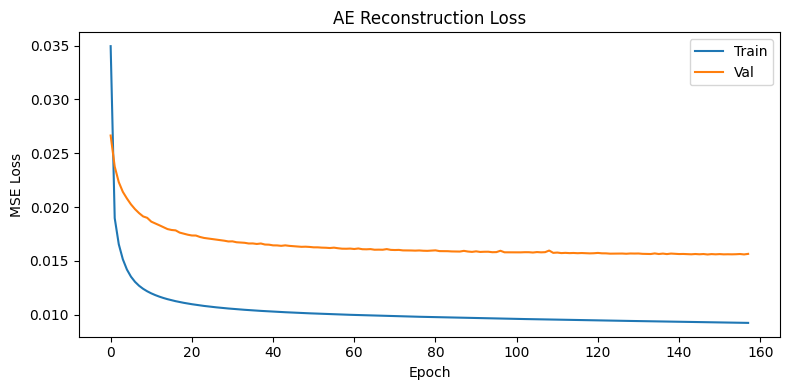

In [101]:
plt.figure(figsize=(8, 4))
plt.plot(results[model_name]["train_losses"], label="Train")
plt.plot(results[model_name]["val_losses"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("AE Reconstruction Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [102]:
STRATEGY = "pad"
AUGMENTATIONS = True
OS = True
OS_TARGET = 2000
US = False
US_TARGET = 50000
ENTIRE_DATASET = False

In [103]:
class WaferClassifierDataset(Dataset):
    def __init__(self, df, strategy="pad", augment=False):
        self.df = df.reset_index(drop=True)
        self.strategy = strategy

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wm = np.array(row["waferMap"], dtype=np.float32) / 2.0

        if self.strategy == "pad":
            wm_array = resize_and_pad(wm)
        else:
            wm_array = np.array(Image.fromarray(wm).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))

        return torch.from_numpy(wm_array).unsqueeze(0), LABEL_MAP[row["failureType"]]

df_train_balanced_clf = balance_df(df_train, oversample=OS, oversample_target=OS_TARGET, undersample=US, undersample_target=US_TARGET)

clf_train_loader = DataLoader(WaferClassifierDataset(
    df_train_balanced_clf, strategy=STRATEGY, augment=AUGMENTATIONS
), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

clf_val_loader = DataLoader(WaferClassifierDataset(
    df_val, strategy=STRATEGY, augment=False
), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

clf_test_loader = DataLoader(WaferClassifierDataset(
    df_test, strategy=STRATEGY, augment=False
), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [104]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report

def encode_loader(model, loader, device):
    model.eval()
    all_z, all_y = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Encoding"):
            x = x.to(device)
            z = model.encode(x)
            all_z.append(z.cpu().numpy())
            all_y.append(y.numpy())
    return np.concatenate(all_z), np.concatenate(all_y)

z_train, y_train = encode_loader(autoenc_trained, clf_train_loader, device)
z_test, y_test = encode_loader(autoenc_trained, clf_test_loader, device)
print(f"Train embeddings: {z_train.shape} | Test embeddings: {z_test.shape}")

Encoding:   0%|          | 0/249 [00:00<?, ?it/s]

Encoding:   0%|          | 0/68 [00:00<?, ?it/s]

Train embeddings: (127132, 128) | Test embeddings: (34590, 128)


### KNN

- We are KNN to evaluate how good our encoder is

In [105]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(z_train, y_train)
y_pred = knn.predict(z_test)

macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"kNN Macro F1: {macro_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASSES, zero_division=0))

kNN Macro F1: 0.6606

              precision    recall  f1-score   support

        none       0.95      1.00      0.97     29486
   Edge-Ring       0.96      0.95      0.96      1936
    Edge-Loc       0.82      0.34      0.48      1038
      Center       0.89      0.75      0.81       859
         Loc       0.81      0.18      0.30       718
     Scratch       0.29      0.20      0.24       239
      Random       0.59      0.83      0.69       173
       Donut       0.63      0.81      0.71       111
   Near-full       0.82      0.77      0.79        30

    accuracy                           0.94     34590
   macro avg       0.75      0.65      0.66     34590
weighted avg       0.94      0.94      0.93     34590



### TSNE

Encoding:   0%|          | 0/249 [00:00<?, ?it/s]

Encoding:   0%|          | 0/68 [00:00<?, ?it/s]

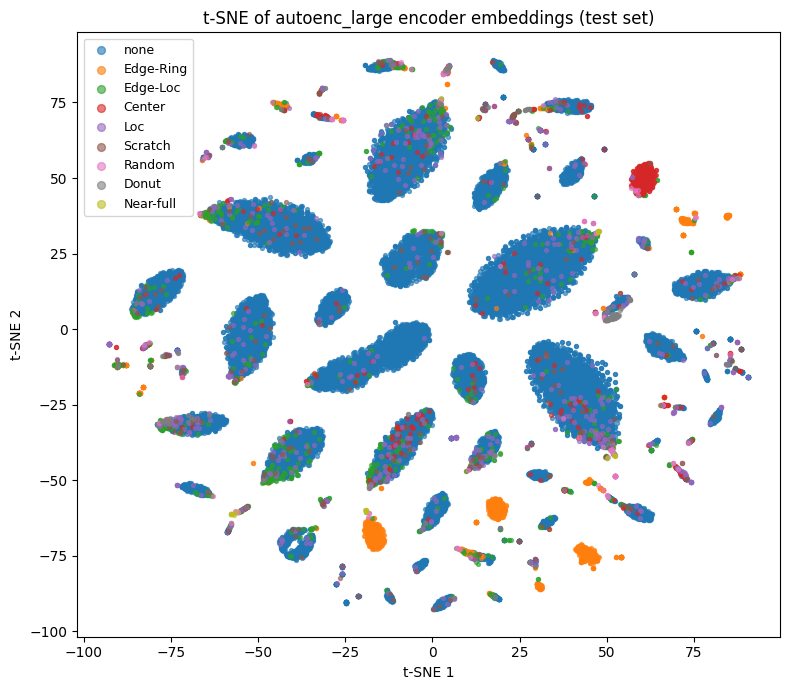

In [106]:
from sklearn.manifold import TSNE

z_train, y_train = encode_loader(autoenc_trained, clf_train_loader, device)
z_test,  y_test  = encode_loader(autoenc_trained, clf_test_loader,  device)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_jobs=-1)
z_test_2d = tsne.fit_transform(z_test)

plt.figure(figsize=(8, 7))
for cls_idx, cls_name in enumerate(CLASSES):
    mask = y_test == cls_idx
    plt.scatter(z_test_2d[mask, 0], z_test_2d[mask, 1], label=cls_name, s=8, alpha=0.6)

plt.legend(markerscale=2, loc="best", fontsize=9)
plt.title(f"t-SNE of {model_name} encoder embeddings (test set)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

### Classifier

- We will finetune our trained encoder for Wafer Classification

In [107]:
class AEClassifier(nn.Module):
    def __init__(self, encoder, latent_dim=128, num_classes=9, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder
        self.freeze_encoder = freeze_encoder
        for param in self.encoder.parameters():
            param.requires_grad = not freeze_encoder

        self.head = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        if self.freeze_encoder:
            with torch.no_grad():
                z = self.encoder.encode(x)
        else:
            z = self.encoder.encode(x)
        return self.head(z)

FINETUNE = True
autoenc_classifier = AEClassifier(copy.deepcopy(autoenc_trained), latent_dim=128, freeze_encoder=not FINETUNE).to(device)
total_params = sum(p.numel() for p in autoenc_classifier.parameters() if p.requires_grad)
print(f"Fine-tune: {FINETUNE} | Trainable parameters: {total_params:,}")

Fine-tune: True | Trainable parameters: 2,831,690


#### Training Loop

In [108]:
learning_rate = 1e-4
weight_decay = 1e-3
MAX_EPOCHS = 50
PATIENCE = 15
LABEL_SMOOTHING = 0.1

if FINETUNE:
    clf_optimizer = torch.optim.AdamW([
        {"params": autoenc_classifier.encoder.parameters(), "lr": learning_rate * 0.1},
        {"params": autoenc_classifier.head.parameters(),    "lr": learning_rate},
    ], weight_decay=weight_decay)
else:
    clf_optimizer = torch.optim.AdamW(autoenc_classifier.head.parameters(), lr=learning_rate, weight_decay=weight_decay)

clf_criterion = nn.CrossEntropyLoss(label_smoothing = LABEL_SMOOTHING)

In [109]:
train_losses, val_losses, val_f1s, val_accs = [], [], [], []
best_val_f1 = 0.0
patience_counter = 0
best_weights = None

start_time = time.time()

for epoch in tqdm(range(MAX_EPOCHS), desc="Epochs"):
    # Train
    autoenc_classifier.train()
    running_loss = 0
    for x, y in tqdm(clf_train_loader, desc=f"Epoch {epoch+1}", leave=False):
        x, y = x.to(device), y.to(device)
        clf_optimizer.zero_grad(set_to_none=True)
        loss = clf_criterion(autoenc_classifier(x), y)
        loss.backward()
        clf_optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(clf_train_loader)

    # Val
    autoenc_classifier.eval()
    running_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in clf_val_loader:
            x, y = x.to(device), y.to(device)
            logits = autoenc_classifier(x)
            running_loss += clf_criterion(logits, y).item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    val_loss = running_loss / len(clf_val_loader)
    val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    val_acc  = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)
    val_accs.append(val_acc)

    # Early stopping on val macro F1
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_counter = 0
        best_weights = {k: v.clone() for k, v in autoenc_classifier.state_dict().items()}
    else:
        patience_counter += 1

    tqdm.write(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Macro F1: {val_f1:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Patience: {patience_counter}/{PATIENCE}"
    )

    if patience_counter >= PATIENCE:
        tqdm.write(f"Early stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time
autoenc_classifier.load_state_dict(best_weights)
tqdm.write(f"Restored best model — val macro F1: {best_val_f1:.4f}")

results["autoenc_classifier"] = {
    "weights": best_weights,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_f1s": val_f1s,
    "val_accs": val_accs,
    "best_val_f1": best_val_f1,
    "epochs_trained": len(train_losses),
    "training_time_sec": elapsed,
    "batch_size": clf_train_loader.batch_size,
    "finetune": FINETUNE,
    "learning_rate_encoder": clf_optimizer.param_groups[0]["lr"] if FINETUNE else None,
    "learning_rate_head": clf_optimizer.param_groups[1]["lr"] if FINETUNE else clf_optimizer.param_groups[0]["lr"],
    "weight_decay": clf_optimizer.param_groups[0]["weight_decay"],
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "seed": SEED,
    "latent_dim": 128,
    "n_train": len(clf_train_loader.dataset),
    "n_val": len(clf_val_loader.dataset),
    "n_test": len(clf_test_loader.dataset),
}

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.7595 | Val Loss: 0.3585 | Val Macro F1: 0.4204 | Val Acc: 0.9132 | Patience: 0/15


Epoch 2:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.3690 | Val Loss: 0.2429 | Val Macro F1: 0.5815 | Val Acc: 0.9334 | Patience: 0/15


...

Epoch 48 | Train Loss: 0.0533 | Val Loss: 0.0795 | Val Macro F1: 0.8655 | Val Acc: 0.9760 | Patience: 0/15


Epoch 49:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 49 | Train Loss: 0.0520 | Val Loss: 0.0832 | Val Macro F1: 0.8551 | Val Acc: 0.9747 | Patience: 1/15


Epoch 50:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 50 | Train Loss: 0.0508 | Val Loss: 0.0808 | Val Macro F1: 0.8463 | Val Acc: 0.9740 | Patience: 2/15
Restored best model — val macro F1: 0.8655


#### Evaluation

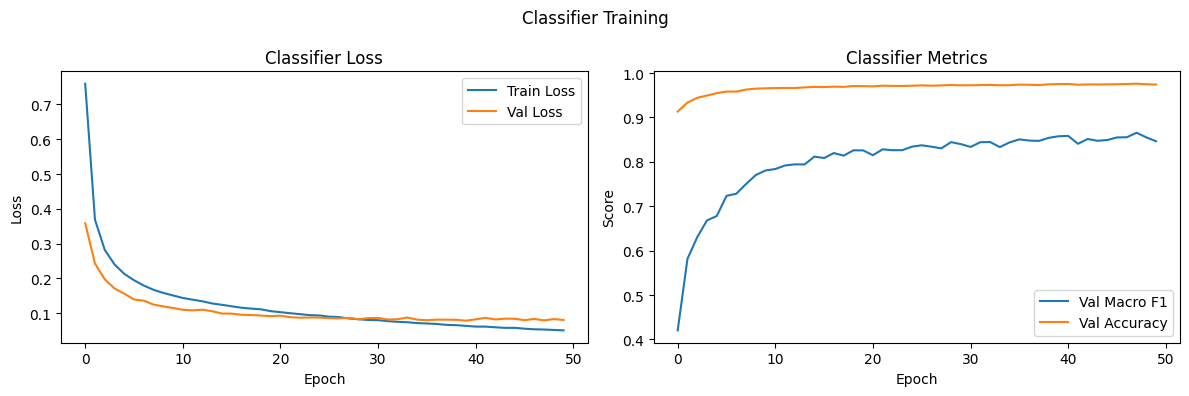

In [110]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(results["autoenc_classifier"]["train_losses"], label="Train Loss")
ax1.plot(results["autoenc_classifier"]["val_losses"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Classifier Loss")
ax1.legend()

ax2.plot(results["autoenc_classifier"]["val_f1s"], label="Val Macro F1")
ax2.plot(results["autoenc_classifier"]["val_accs"], label="Val Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Classifier Metrics")
ax2.legend()

plt.suptitle("Classifier Training", fontsize=12)
plt.tight_layout()
plt.show()

In [111]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, loader, run_name, train_losses, val_losses):
    model.eval()
    all_preds, all_labels = [], []
    test_running_loss = 0
    criterion_eval = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Evaluating {run_name}"):
            x, y = x.to(device), y.to(device)
            out   = model(x)
            test_running_loss += criterion_eval(out, y).item()
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())
    test_loss  = round(test_running_loss / len(loader), 4)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    report = classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    results[run_name].update({
        "accuracy":        round(report["accuracy"], 4),
        "macro_f1":        round(report["macro avg"]["f1-score"], 4),
        "macro_precision": round(report["macro avg"]["precision"], 4),
        "macro_recall":    round(report["macro avg"]["recall"], 4),
        "train_losses":    train_losses,
        "val_losses":      val_losses,
        "best_val_loss":   round(min(val_losses), 4),
        "test_loss":       test_loss,
        "preds":           all_preds,
        "labels":          all_labels,
        **{f"f1_{cls}": round(report[cls]["f1-score"], 4) for cls in CLASSES},
    })
    print(f"\n--- {run_name} ---")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"\nPer-class Metrics:")
    print(f"{'Class':<12} {'F1':>10} {'Precision':>10} {'Recall':>10}")
    print("-" * 46)
    for cls in CLASSES:
        print(
            f"{cls:<12} "
            f"{report[cls]['f1-score']:>10.4f} "
            f"{report[cls]['precision']:>10.4f} "
            f"{report[cls]['recall']:>10.4f}"
        )
    print("-" * 46)
    print(
        f"{'macro avg':<12} "
        f"{report['macro avg']['f1-score']:>10.4f} "
        f"{report['macro avg']['precision']:>10.4f} "
        f"{report['macro avg']['recall']:>10.4f}"
    )
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")

In [112]:
evaluate_model(
    autoenc_classifier,
    clf_test_loader,
    "autoenc_classifier",
    results["autoenc_classifier"]["train_losses"],
    results["autoenc_classifier"]["val_losses"]
)

Evaluating autoenc_classifier:   0%|          | 0/68 [00:00<?, ?it/s]


--- autoenc_classifier ---
Test Loss: 0.0910

Per-class Metrics:
Class                F1  Precision     Recall
----------------------------------------------
none             0.9895     0.9851     0.9940
Edge-Ring        0.9754     0.9772     0.9737
Edge-Loc         0.8275     0.8574     0.7996
Center           0.9383     0.9467     0.9302
Loc              0.7092     0.7796     0.6504
Scratch          0.4697     0.5575     0.4059
Random           0.9112     0.9034     0.9191
Donut            0.8261     0.7983     0.8559
Near-full        0.9333     0.9333     0.9333
----------------------------------------------
macro avg        0.8423     0.8598     0.8291

Overall Accuracy: 0.9733


### Save the model

In [113]:
def save_checkpoint(model, results, file_name):
    save_dir = Path("checkpoints")
    save_dir.mkdir(parents=True, exist_ok=True)

    save_path = save_dir / f"{file_name}.pt"

    torch.save({
        "model_state_dict": model.state_dict(),
        "results": results
    }, save_path)

    print(f"Checkpoint saved to: {save_path}")

In [114]:
save_checkpoint(model, results[model_name], f"{model_name}_dlabeled")

Checkpoint saved to: checkpoints/autoenc_large_dlabeled.pt


In [115]:
save_checkpoint(autoenc_classifier, results["autoenc_classifier"], "autoenc_classifier_dlabeled")

Checkpoint saved to: checkpoints/autoenc_classifier_dlabeled.pt
